In [4]:
import kagglehub
import pandas as pd
import numpy as np
import joblib
import os

# Get the path to the dataset
path = str(kagglehub.dataset_download("moltean/fruits"))
print("Path to dataset files:", path)

def create_csv(dataset_type):
    dataset_path = f'{path}/fruits-360_100x100/fruits-360/{dataset_type}'
    image_paths = []
    labels = []

    for label in os.listdir(dataset_path):
        label_path = os.path.join(dataset_path, label)
        if os.path.isdir(label_path):
            for image_name in os.listdir(label_path):
                if image_name.endswith('.jpg'):
                    image_paths.append(os.path.join(label, image_name))
                    labels.append(label)

    df = pd.DataFrame({
        'image': image_paths,
        'label': labels
    })

    csv_filename = f'fruits_{dataset_type.lower()}.csv'
    df.to_csv(csv_filename, index=False)
    print(f"{dataset_type} CSV saved at: {os.path.join(os.getcwd(), csv_filename)}")

# Create CSVs for training and testing datasets
create_csv('Training')
create_csv('Test')

train_csv = os.path.join(os.getcwd(), 'fruits_training.csv')
test_csv = os.path.join(os.getcwd(), 'fruits_test.csv')

# Load them into DataFrames
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

# Check the first few rows
print(train_df.head())
print(test_df.head())

def limit_classes(df, num_classes=50, samples_per_class=None, random_state=42):
    # Pick a subset of classes
    unique_classes = df["label"].unique()
    np.random.seed(random_state)
    selected_classes = np.random.choice(unique_classes, num_classes, replace=False)

    # Filter down to those classes
    df = df[df["label"].isin(selected_classes)]

    # Optionally, sample equal images per class
    if samples_per_class:
        df = df.groupby("label").apply(
            lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=random_state)
        ).reset_index(drop=True)

    return df




imgPerClass = 50

#train_df = limit_classes(train_df, samples_per_class=imgPerClass)
#test_df = limit_classes(test_df, samples_per_class=imgPerClass)

Path to dataset files: /root/.cache/kagglehub/datasets/moltean/fruits/versions/53
Training CSV saved at: /root/python/Fruit-Classification/fruits_training.csv
Test CSV saved at: /root/python/Fruit-Classification/fruits_test.csv
                       image       label
0  Cucumber 5/r0_124_100.jpg  Cucumber 5
1    Cucumber 5/r1_2_100.jpg  Cucumber 5
2    Cucumber 5/r2_1_100.jpg  Cucumber 5
3  Cucumber 5/r0_168_100.jpg  Cucumber 5
4  Cucumber 5/r2_201_100.jpg  Cucumber 5
                       image       label
0  Cucumber 5/r2_115_100.jpg  Cucumber 5
1  Cucumber 5/r1_135_100.jpg  Cucumber 5
2  Cucumber 5/r0_175_100.jpg  Cucumber 5
3  Cucumber 5/r2_111_100.jpg  Cucumber 5
4   Cucumber 5/r1_71_100.jpg  Cucumber 5


In [5]:
from sklearn.metrics import accuracy_score, classification_report
from concurrent.futures import ProcessPoolExecutor
from sklearn.preprocessing import LabelEncoder
from functools import partial
from PIL import Image
import numpy as np
import os

size = (64, 64)

def process_image(row, base_path, crop_size):
    image_path = os.path.join(base_path, row['image'])
    img = Image.open(image_path).convert('RGB')
    img = img.resize(crop_size)
    # use float32 for smaller memory footprint
    img_array = np.array(img, dtype=np.float32) / 255.0
    label = row['label']
    return img_array, label


def load_parallel(csv_df, base_path, crop_size=size, n_jobs=30):
    rows = csv_df.to_dict("records")
    n_samples = len(rows)
    
    # pre-allocate big array once
    X = np.empty((n_samples, crop_size[0], crop_size[1], 3), dtype=np.float32)
    y = [None] * n_samples

    with ProcessPoolExecutor(max_workers=n_jobs) as executor:
        func = partial(process_image, base_path=base_path, crop_size=crop_size)
        for i, (img_array, label) in enumerate(executor.map(func, rows, chunksize=50)):
            X[i] = img_array
            y[i] = label

    return X, np.array(y)


# usage
base_path_train = os.path.join(path, "fruits-360_100x100/fruits-360/Training")
X_train, y_train = load_parallel(train_df, base_path_train)

base_path_val = os.path.join(path, "fruits-360_100x100/fruits-360/Test")
X_val, y_val = load_parallel(test_df, base_path_val)

print("Train:", X_train.shape, "Val:", X_val.shape)
print("Unique train labels:", np.unique(y_train))
print("Unique val labels:", np.unique(y_val))

# flatten for models that don’t support images directly
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)

# encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)

print(y_train_enc[:20])
print(y_val_enc[:20])


Train: (110744, 64, 64, 3) Val: (36947, 64, 64, 3)
Unique train labels: ['Apple 10' 'Apple 11' 'Apple 12' 'Apple 13' 'Apple 14' 'Apple 17'
 'Apple 18' 'Apple 19' 'Apple 5' 'Apple 6' 'Apple 7' 'Apple 8' 'Apple 9'
 'Apple Braeburn 1' 'Apple Core 1' 'Apple Crimson Snow 1' 'Apple Golden 1'
 'Apple Golden 2' 'Apple Golden 3' 'Apple Granny Smith 1'
 'Apple Pink Lady 1' 'Apple Red 1' 'Apple Red 2' 'Apple Red 3'
 'Apple Red Delicious 1' 'Apple Red Yellow 1' 'Apple Red Yellow 2'
 'Apple Rotten 1' 'Apple hit 1' 'Apple worm 1' 'Apricot 1' 'Avocado 1'
 'Avocado Black 1' 'Avocado Green 1' 'Avocado ripe 1' 'Banana 1'
 'Banana 3' 'Banana 4' 'Banana Lady Finger 1' 'Banana Red 1' 'Beans 1'
 'Beetroot 1' 'Blackberrie 1' 'Blackberrie 2' 'Blackberrie half rippen 1'
 'Blackberrie not rippen 1' 'Blueberry 1' 'Cabbage red 1'
 'Cabbage white 1' 'Cactus fruit 1' 'Cactus fruit green 1'
 'Cactus fruit red 1' 'Caju seed 1' 'Cantaloupe 1' 'Cantaloupe 2'
 'Carambula 1' 'Carrot 1' 'Cauliflower 1' 'Cherimoya 1' 'Cher

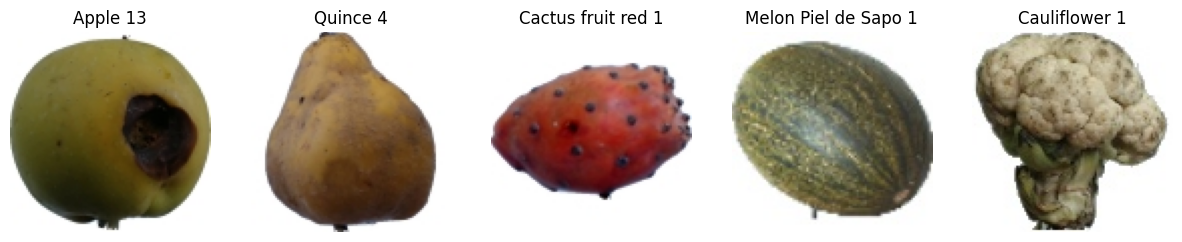

In [6]:
import matplotlib.pyplot as plt
import random
from PIL import Image
import os

# Pick 5 random rows
sample_rows = train_df.sample(5, random_state=42)

# Set base path
base_path_train = os.path.join(path, "fruits-360_100x100/fruits-360/Training")

# Create figure
plt.figure(figsize=(15, 5))

for i, (_, row) in enumerate(sample_rows.iterrows(), 1):
    img_path = os.path.join(base_path_train, row['image'])
    img = Image.open(img_path).convert('RGB')
    
    plt.subplot(1, 5, i)
    plt.imshow(img)
    plt.title(row['label'])
    plt.axis('off')

plt.show()


In [7]:
"""from sklearn.decomposition import PCA


# Apply PCA and overwrite X_train/X_val
n_components = 0.95
pca = PCA(n_components=n_components, random_state=42)
X_train = pca.fit_transform(X_train)
X_val = pca.transform(X_val)

print("Original shape after flattening:", X_train.shape[0], "features:", X_train.shape[1])"""


'from sklearn.decomposition import PCA\n\n\n# Apply PCA and overwrite X_train/X_val\nn_components = 0.95\npca = PCA(n_components=n_components, random_state=42)\nX_train = pca.fit_transform(X_train)\nX_val = pca.transform(X_val)\n\nprint("Original shape after flattening:", X_train.shape[0], "features:", X_train.shape[1])'

In [8]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=len(np.unique(y_train_enc)),
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=1,
    eval_metric="mlogloss",
)

xgb_clf.fit(
    X_train_flat, y_train_enc,
    eval_set=[(X_val_flat, y_val_enc)],
    verbose=True
)

joblib.dump(xgb_clf, "xgb_model.joblib")

[0]	validation_0-mlogloss:2.30451
[1]	validation_0-mlogloss:2.05374
[2]	validation_0-mlogloss:1.90181
[3]	validation_0-mlogloss:1.78531
[4]	validation_0-mlogloss:1.68806
[5]	validation_0-mlogloss:1.60857
[6]	validation_0-mlogloss:1.53569
[7]	validation_0-mlogloss:1.47153
[8]	validation_0-mlogloss:1.41323
[9]	validation_0-mlogloss:1.36156
[10]	validation_0-mlogloss:1.31357
[11]	validation_0-mlogloss:1.26856
[12]	validation_0-mlogloss:1.22680
[13]	validation_0-mlogloss:1.18768
[14]	validation_0-mlogloss:1.15033
[15]	validation_0-mlogloss:1.11558
[16]	validation_0-mlogloss:1.08303
[17]	validation_0-mlogloss:1.05296
[18]	validation_0-mlogloss:1.02370
[19]	validation_0-mlogloss:0.99606
[20]	validation_0-mlogloss:0.96974
[21]	validation_0-mlogloss:0.94466
[22]	validation_0-mlogloss:0.92075
[23]	validation_0-mlogloss:0.89800
[24]	validation_0-mlogloss:0.87666
[25]	validation_0-mlogloss:0.85580
[26]	validation_0-mlogloss:0.83595
[27]	validation_0-mlogloss:0.81672
[28]	validation_0-mlogloss:0.7

['xgb_model.joblib']

In [9]:
xgb_clf = joblib.load("xgb_model.joblib")
y_pred = xgb_clf.predict(X_val_flat)
acc = accuracy_score(y_val_enc, y_pred)
print(f"Validation accuracy: {acc:.4f}")
print(classification_report(
    y_val_enc,
    y_pred,
    target_names=[str(c) for c in le.classes_]
))

Validation accuracy: 0.9218
                           precision    recall  f1-score   support

                 Apple 10       0.94      1.00      0.97       231
                 Apple 11       1.00      1.00      1.00       142
                 Apple 12       0.95      1.00      0.97       154
                 Apple 13       0.98      1.00      0.99       235
                 Apple 14       0.97      1.00      0.99       154
                 Apple 17       1.00      1.00      1.00       201
                 Apple 18       1.00      1.00      1.00       160
                 Apple 19       1.00      1.00      1.00       241
                  Apple 5       1.00      1.00      1.00       146
                  Apple 6       0.93      1.00      0.96       157
                  Apple 7       1.00      1.00      1.00       229
                  Apple 8       1.00      1.00      1.00       228
                  Apple 9       0.97      1.00      0.98       231
         Apple Braeburn 1       0

In [10]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(max_depth=20, 
                                min_samples_leaf=2,
                                random_state=42)
dt_clf.fit(X_train_flat, y_train_enc)

y_pred_dt = dt_clf.predict(X_val_flat)
joblib.dump(dt_clf, "dt_model.joblib")
print("Decision Tree Accuracy:", accuracy_score(y_val_enc, y_pred_dt))
print(classification_report(y_val_enc, y_pred_dt, target_names=le.classes_))

Decision Tree Accuracy: 0.6922618886513113
                           precision    recall  f1-score   support

                 Apple 10       0.89      0.77      0.83       231
                 Apple 11       0.89      0.77      0.83       142
                 Apple 12       0.79      0.69      0.74       154
                 Apple 13       0.78      0.79      0.78       235
                 Apple 14       0.57      0.61      0.59       154
                 Apple 17       0.56      0.90      0.69       201
                 Apple 18       0.77      0.80      0.79       160
                 Apple 19       0.85      0.90      0.87       241
                  Apple 5       0.98      0.95      0.97       146
                  Apple 6       0.38      0.75      0.50       157
                  Apple 7       0.72      0.75      0.73       229
                  Apple 8       0.93      0.77      0.84       228
                  Apple 9       0.67      0.72      0.69       231
         Apple Bra

In [11]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=500, multi_class='multinomial', solver='saga', n_jobs=-1)
lr_clf.fit(X_train_flat, y_train_enc)

y_pred_lr = lr_clf.predict(X_val_flat)
joblib.dump(lr_clf, "lr_model.joblib")
print("Logistic Regression Accuracy:", accuracy_score(y_val_enc, y_pred_lr))
print(classification_report(y_val_enc, y_pred_lr, target_names=le.classes_))


/root/python/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_clf.fit(X_train_flat, y_train_enc)

y_pred_knn = knn_clf.predict(X_val_flat)
joblib.dump(knn_clf, "knn_model.joblib")
print("kNN Accuracy:", accuracy_score(y_val_enc, y_pred_knn))
print(classification_report(y_val_enc, y_pred_knn, target_names=le.classes_))


kNN Accuracy: 0.798
                          precision    recall  f1-score   support

                Apple 14       0.65      0.98      0.78        50
                Apple 18       0.94      0.88      0.91        50
                 Apple 5       0.81      1.00      0.89        50
                 Apple 6       0.53      1.00      0.69        50
          Apple Golden 1       0.82      0.66      0.73        50
          Apple Golden 2       0.72      0.86      0.78        50
         Avocado Green 1       0.69      0.86      0.77        50
    Banana Lady Finger 1       1.00      0.50      0.67        50
                 Beans 1       1.00      1.00      1.00        50
              Beetroot 1       0.62      0.56      0.59        50
Blackberrie not rippen 1       1.00      0.78      0.88        50
    Cactus fruit green 1       0.93      0.74      0.82        50
             Carambula 1       0.90      0.70      0.79        50
                Carrot 1       0.71      1.00      0.83

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)
rf_clf.fit(X_train_flat, y_train_enc)

y_pred_rf = rf_clf.predict(X_val_flat)
joblib.dump(rf_clf, "rf_model.joblib")
print("Random Forest Accuracy:", accuracy_score(y_val_enc, y_pred_rf))
print(classification_report(y_val_enc, y_pred_rf, target_names=le.classes_))


Random Forest Accuracy: 0.9441361950902645
                           precision    recall  f1-score   support

                 Apple 10       1.00      1.00      1.00       231
                 Apple 11       1.00      1.00      1.00       142
                 Apple 12       1.00      1.00      1.00       154
                 Apple 13       1.00      1.00      1.00       235
                 Apple 14       1.00      1.00      1.00       154
                 Apple 17       1.00      1.00      1.00       201
                 Apple 18       1.00      1.00      1.00       160
                 Apple 19       1.00      1.00      1.00       241
                  Apple 5       1.00      1.00      1.00       146
                  Apple 6       0.83      1.00      0.90       157
                  Apple 7       1.00      1.00      1.00       229
                  Apple 8       1.00      1.00      1.00       228
                  Apple 9       1.00      1.00      1.00       231
         Apple Bra

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
# Flatten images: (n_samples, 64, 64, 3) -> (n_samples, 12288)
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)

# Optional: reduce dimensionality with PCA for speed and performance
pca = PCA(n_components=200, random_state=42)  # keep 200 components
X_train_pca = pca.fit_transform(X_train_flat)
X_val_pca = pca.transform(X_val_flat)

# Train kNN model
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)  # try k=5 first
knn.fit(X_train_pca, y_train_enc)
joblib.dump(knn, "knn.joblib")

# Predict
y_pred_knn = knn.predict(X_val_pca)

# Evaluate
acc = accuracy_score(y_val_enc, y_pred_knn)
print("kNN Accuracy:", acc)
#print(classification_report(y_val_enc, y_pred_knn, target_names=label_encoder.classes_))
